# Basic Computer Vision - OpenCV Programming Homework

## CLAHE Image Enhancement

## Preliminary Tests and Development

The following cells document the preliminary implementation and testing of image loading, CLAHE processing, visualization, and command-line parameter parsing.

In [1]:
import cv2

print("OpenCV version:", cv2.__version__)


OpenCV version: 5.0.0


In [2]:
image = cv2.imread("Norway.jpg", cv2.IMREAD_GRAYSCALE)

print(image.shape)

(1280, 1706)


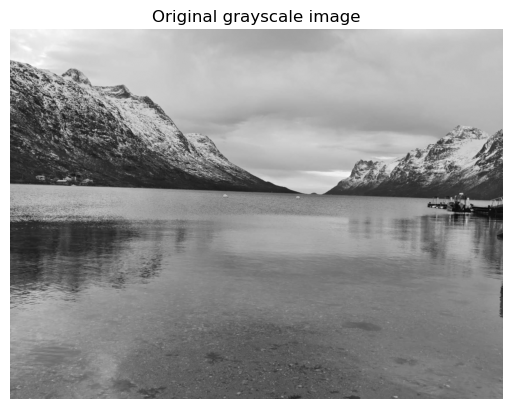

In [3]:
import matplotlib.pyplot as plt

plt.imshow(image, cmap="gray")
plt.title("Original grayscale image")
plt.axis("off")
plt.show()

In [4]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

clahe_image = clahe.apply(image)

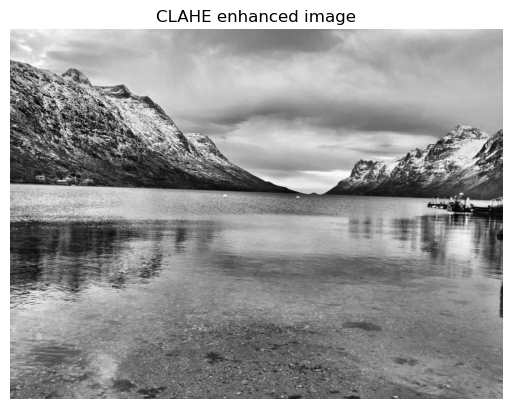

In [5]:
plt.imshow(clahe_image, cmap="gray")
plt.title("CLAHE enhanced image")
plt.axis("off")
plt.show()

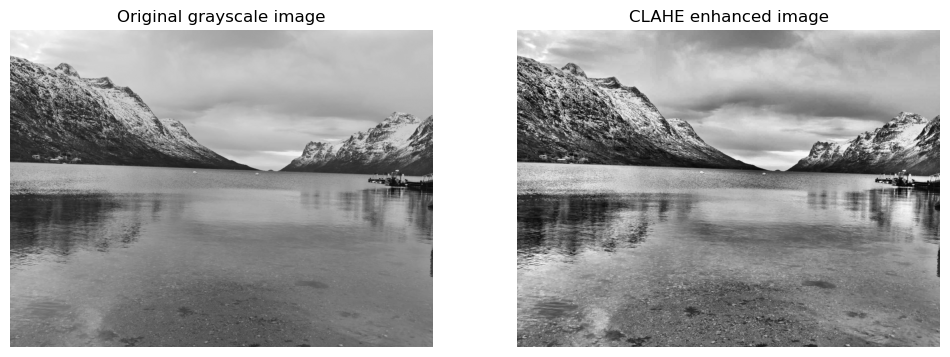

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original grayscale image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clahe_image, cmap="gray")
plt.title("CLAHE enhanced image")
plt.axis("off")

plt.show()

In [7]:
clip_limit = 2.0
tile_size = 8

clahe = cv2.createCLAHE(
    clipLimit=clip_limit,
    tileGridSize=(tile_size, tile_size)
)

clahe_image = clahe.apply(image)

In [8]:
import argparse

In [9]:
parser = argparse.ArgumentParser()

parser.add_argument("--clip", type=float, default=2.0)
parser.add_argument("--tile", type=int, default=8)

_StoreAction(option_strings=['--tile'], dest='tile', nargs=None, const=None, default=8, type=<class 'int'>, choices=None, required=False, help=None, metavar=None, deprecated=False)

In [10]:
args, unknown = parser.parse_known_args()

clip_limit = args.clip
tile_size = args.tile

print("Clip limit:", clip_limit)
print("Tile size:", tile_size)

Clip limit: 2.0
Tile size: 8


In [11]:
clahe = cv2.createCLAHE(
    clipLimit=clip_limit,
    tileGridSize=(tile_size, tile_size)
)

result = clahe.apply(image)

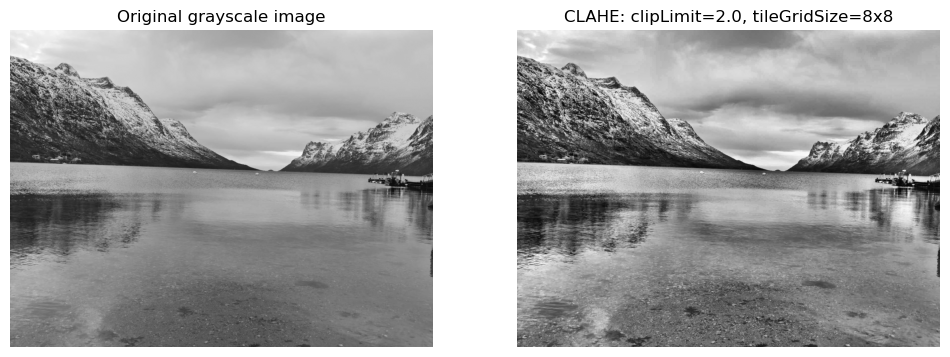

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original grayscale image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result, cmap="gray")
plt.title(f"CLAHE: clipLimit={clip_limit}, tileGridSize={tile_size}x{tile_size}")
plt.axis("off")

plt.show()

In [13]:
test_args = ["--clip", "3.0", "--tile", "16"]

args = parser.parse_args(test_args)

print("Clip limit:", args.clip)
print("Tile size:", args.tile)

Clip limit: 3.0
Tile size: 16


In [14]:
# Load the input image in grayscale
image_path = "Norway.jpg"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError(f"Could not load image: {image_path}")

print("Image loaded successfully.")
print("Image size:", image.shape)

Image loaded successfully.
Image size: (1280, 1706)


In [15]:
# Define command-line arguments
parser = argparse.ArgumentParser(
    description="Apply CLAHE to a grayscale image."
)

parser.add_argument(
    "--clip",
    type=float,
    default=2.0,
    help="Contrast limiting threshold"
)

parser.add_argument(
    "--tile",
    type=int,
    default=8,
    help="Tile grid size"
)

_StoreAction(option_strings=['--tile'], dest='tile', nargs=None, const=None, default=8, type=<class 'int'>, choices=None, required=False, help='Tile grid size', metavar=None, deprecated=False)

In [16]:
# Read the command-line arguments
args, unknown = parser.parse_known_args()

clip_limit = args.clip
tile_size = args.tile

print("CLAHE parameters:")
print("  Clip limit:", clip_limit)
print("  Tile grid size:", tile_size, "x", tile_size)

CLAHE parameters:
  Clip limit: 2.0
  Tile grid size: 8 x 8


In [17]:
# Create and apply the CLAHE transform
clahe = cv2.createCLAHE(
    clipLimit=clip_limit,
    tileGridSize=(tile_size, tile_size)
)

result = clahe.apply(image)


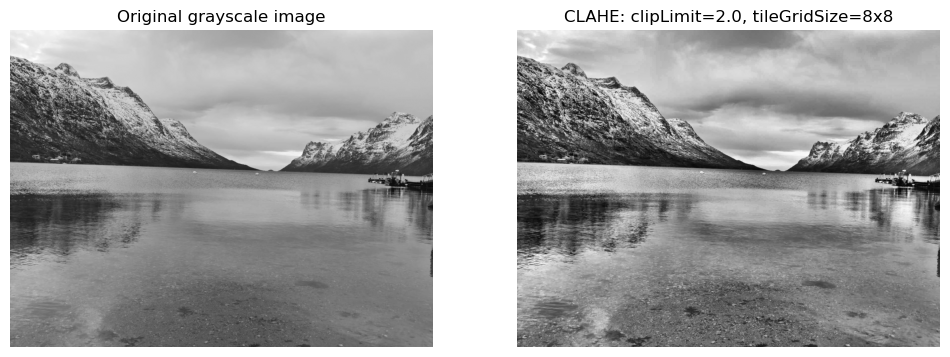

In [18]:
# Display the original and CLAHE-enhanced images
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original grayscale image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result, cmap="gray")
plt.title(
    f"CLAHE: clipLimit={clip_limit}, "
    f"tileGridSize={tile_size}x{tile_size}"
)
plt.axis("off")

plt.show()

In [19]:
import sys

sys.argv = [
    "BCV_CLAHE_Homework.ipynb",
    "--clip", "3.0",
    "--tile", "16"
]

args = parser.parse_args()

print("Command-line clip limit:", args.clip)
print("Command-line tile size:", args.tile)

Command-line clip limit: 3.0
Command-line tile size: 16


## Exercise 1 - Simple OpenCV Noninteractive Pipeline

This program applies Contrast Limited Adaptive Histogram Equalization (CLAHE) to a grayscale image. The contrast limiting threshold and tile grid size are provided as command-line parameters.

In [21]:
sys.argv = [
    "BCV_CLAHE_Homework.ipynb",
    "--clip", "3.0",
    "--tile", "16"
]

clipLimit = 3.0
tileGridSize = 16 x 16


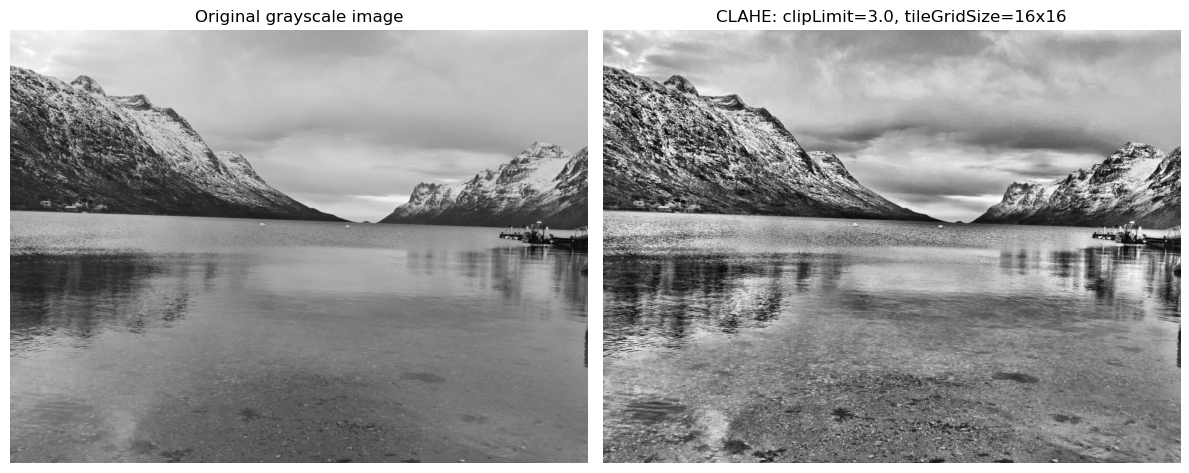

In [22]:
import cv2
import argparse
import sys
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Command-line arguments
# ---------------------------------------------------------

parser = argparse.ArgumentParser(
    description="Apply CLAHE to a grayscale image."
)

parser.add_argument(
    "--clip",
    type=float,
    default=2.0,
    help="Contrast limiting threshold (default: 2.0)"
)

parser.add_argument(
    "--tile",
    type=int,
    default=8,
    help="Tile grid size (default: 8)"
)

# In Jupyter Notebook, sys.argv may contain arguments used by Jupyter itself.
# parse_known_args() ignores these unrelated arguments.
args, unknown = parser.parse_known_args()

clip_limit = args.clip
tile_size = args.tile

# ---------------------------------------------------------
# Load image
# ---------------------------------------------------------

image_path = "Norway.jpg"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError(f"Could not load image: {image_path}")

# ---------------------------------------------------------
# CLAHE processing
# ---------------------------------------------------------

clahe = cv2.createCLAHE(
    clipLimit=clip_limit,
    tileGridSize=(tile_size, tile_size)
)

result = clahe.apply(image)

# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------

print(f"clipLimit = {clip_limit}")
print(f"tileGridSize = {tile_size} x {tile_size}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original grayscale image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result, cmap="gray")
plt.title(
    f"CLAHE: clipLimit={clip_limit}, "
    f"tileGridSize={tile_size}x{tile_size}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

## Exercise 2 - Preliminary Tests and Development

The following cells test the OpenCV GUI and Trackbar functionality before implementing the complete interactive CLAHE pipeline.

In [23]:
# Test an OpenCV GUI window

test_window = "OpenCV GUI Test"

cv2.namedWindow(test_window, cv2.WINDOW_NORMAL)
cv2.resizeWindow(test_window, 800, 600)

cv2.imshow(test_window, image)

print("Press any key in the image window to close it.")

cv2.waitKey(0)
cv2.destroyAllWindows()

Press any key in the image window to close it.


In [24]:
# Test OpenCV Trackbar

trackbar_window = "Trackbar Test"

cv2.namedWindow(trackbar_window, cv2.WINDOW_NORMAL)
cv2.resizeWindow(trackbar_window, 800, 600)

def nothing(value):
    pass

cv2.createTrackbar(
    "Tile Size",
    trackbar_window,
    8,
    32,
    nothing
)

cv2.imshow(trackbar_window, image)

print("Move the Trackbar to test it.")
print("Press ESC in the image window to close.")

while True:
    key = cv2.waitKey(20) & 0xFF

    if key == 27:  # ESC
        break

cv2.destroyAllWindows()

Move the Trackbar to test it.
Press ESC in the image window to close.


## Exercise 2 - Simple OpenCV Interactive Pipeline

This program provides an interactive GUI for CLAHE processing. Two OpenCV Trackbars allow the user to adjust the contrast limiting threshold and the tile grid size in real time.

In [26]:
# Exercise 2: Interactive CLAHE pipeline using OpenCV Trackbars

window_name = "Interactive CLAHE"

cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
cv2.resizeWindow(window_name, 1200, 700)


# Empty callback used while creating the Trackbars
def nothing(value):
    pass


# Create both Trackbars first
cv2.createTrackbar(
    "Clip Limit x10",
    window_name,
    20,       # Initial value = 2.0
    100,      # Maximum value = 10.0
    nothing
)

cv2.createTrackbar(
    "Tile Size",
    window_name,
    8,        # Initial value = 8
    32,       # Maximum value = 32
    nothing
)


def update_clahe():
    # Read current Trackbar positions
    clip_position = cv2.getTrackbarPos("Clip Limit x10", window_name)
    tile_size = cv2.getTrackbarPos("Tile Size", window_name)

    # Prevent zero values
    clip_limit = max(1, clip_position) / 10.0
    tile_size = max(1, tile_size)

    # Apply CLAHE with the current parameters
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=(tile_size, tile_size)
    )

    enhanced = clahe.apply(image)

    # Display original and enhanced images side by side
    display = cv2.hconcat([image, enhanced])
    cv2.imshow(window_name, display)


print("Left: original image | Right: CLAHE-enhanced image")
print("Move the Trackbars to adjust the CLAHE parameters.")
print("Press ESC in the image window to close.")

while True:
    # Update the CLAHE result continuously
    update_clahe()

    key = cv2.waitKey(20) & 0xFF

    if key == 27:  # ESC
        break

cv2.destroyAllWindows()

Left: original image | Right: CLAHE-enhanced image
Move the Trackbars to adjust the CLAHE parameters.
Press ESC in the image window to close.
